In [202]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)


from itertools import combinations
from functools import partial
from typing import Optional

from mlforecast import MLForecast
from mlforecast.target_transforms import GlobalSklearnTransformer
from mlforecast.utils import PredictionIntervals
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import FunctionTransformer
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import fourier, pipeline, trend

from fpppy.models import LinearRegression

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#569CC6", "#D55F03", "#13A076"])

def plot_diagnostics(
    forecaster,
    model: Optional[str] = None,
    n_lags: int = None,
    target_col: str = "y",
    time_col: str = "ds",
):
    # Plot first model only if no model spec is given
    if model is None:
        model = list(forecaster.models.keys())[0]
    fitted = forecaster.forecast_fitted_values().assign(
        resid=lambda x: x[target_col] - x[model]
    )

    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(fitted[time_col], fitted["resid"], marker='.')
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        fitted["resid"], ax=ax, zero=False, lags=n_lags,
        bartlett_confint=False, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel='acf')

    ax = axes["hist"]
    ax.hist(fitted["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

def adj_r2_score(y, y_hat, T, k):
    r2 = r2_score(y, y_hat)
    return 1 - (1 - r2) * (T - 1) / (T - k - 1)

def aic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + 2 * (k + 2)

def aicc_score(y, y_hat, T, k):
    aic = aic_score(y, y_hat, T, k)
    return aic + (2 * (k + 2) * (k + 3)) / (T - k - 3)

def bic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + (k + 2) * np.log(T)

def cv_score(mf, model='LinearRegression'):
    fitted_model = mf.models_[model]
    X = fitted_model._X_design
    y = fitted_model._y
    e = fitted_model._residuals
    XtX_inv = np.linalg.pinv(X.T @ X)
    h = np.sum((X @ XtX_inv) * X, axis=1)
    return np.nanmean((e / (1 - h))**2)

# 7.1 The linear model

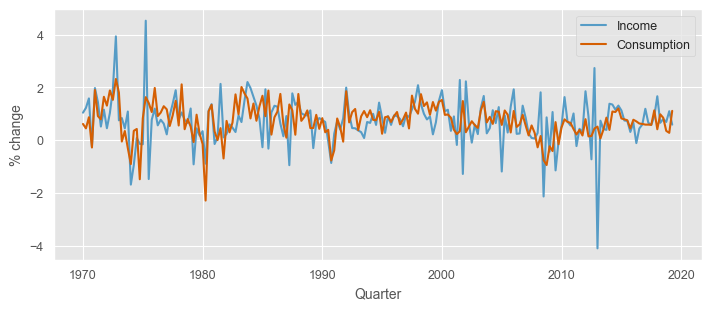

In [203]:
import pandas as pd
import matplotlib.pyplot as plt

us_change = pd.read_csv("../data/fpp3/us_change.csv")

us_change["ds"] = pd.PeriodIndex(
    us_change["Quarter"].str.replace(" ", "", regex=False),
    freq="Q"
).to_timestamp()

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(us_change["ds"], us_change["Income"], label="Income")
ax.plot(us_change["ds"], us_change["Consumption"], label="Consumption")

ax.set(xlabel="Quarter", ylabel="% change")
ax.legend()

plt.show()

In [204]:
us_change

,Quarter,Consumption,Income,Production,Savings,Unemployment,ds
0,1970 Q1,0.619,1.045,-2.452,5.299,0.9,1970-01-01
1,1970 Q2,0.452,1.226,-0.551,7.790,0.5,1970-04-01
2,1970 Q3,0.873,1.585,-0.359,7.404,0.5,1970-07-01
3,1970 Q4,-0.272,-0.240,-2.186,1.170,0.7,1970-10-01
4,1971 Q1,1.901,1.976,1.910,3.536,-0.1,1971-01-01
...,...,...,...,...,...,...,...
193,2018 Q2,0.983,0.662,1.117,-2.724,0.0,2018-04-01
194,2018 Q3,0.853,0.806,1.257,-0.086,-0.3,2018-07-01
195,2018 Q4,0.357,0.695,0.948,5.031,0.2,2018-10-01
196,2019 Q1,0.283,1.101,-0.488,9.760,-0.1,2019-01-01


In [205]:
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

us_change = us_change.assign(
    y=us_change["Consumption"],
    unique_id="US"
)


mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(us_change[["ds", "y", "unique_id", "Income"]],
  fitted=True, static_features=[])

MLForecast(models=[LinearRegression], freq=QS-OCT, lag_features=[], date_features=[], num_threads=1)

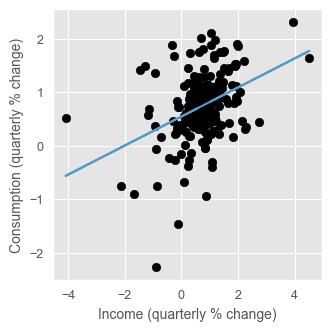

In [206]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
ax.scatter(us_change["Income"], us_change["y"], color="k")
ax.plot(us_change["Income"],
  mf.forecast_fitted_values()["LinearRegression"])
ax.set(xlabel="Income (quarterly % change)",
  ylabel="Consumption (quarterly % change)")
plt.show()

In [207]:
def print_regression_summary_from_model(model):
    X = model._X.values.astype(float)
    y = model._y
    resid = model._residuals
    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    dof = n - p - 1

    percentiles = [0, 25, 50, 75, 100]
    labels = ["Min", "1Q", "Median", "3Q", "Max"]
    percentiles_resid = np.percentile(resid, percentiles)
    resid_summary = pd.DataFrame({
        label: [percentile]
        for label, percentile in zip(labels, percentiles_resid)
    }, index=[""])

    coef = np.insert(model.coef_, 0, model.intercept_)
    rss = np.sum(resid ** 2)
    mse = rss / dof
    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

    names = ["(Intercept)"] + model._var_names

    stars_lookup = ["***", "**", "*", "."]
    stars_conds = [
        p_values < 0.001,
        p_values < 0.01,
        p_values < 0.05,
        p_values < 0.1
    ]
    stars = np.select(stars_conds, stars_lookup, default="")

    coef_summary = pd.DataFrame({
        "Estimate": coef,
        "Std. Error": se_beta,
        "t value": t_stats,
        "Pr(>|t|)": p_values,
        "": stars
    }, index=names)

    r_squared = model.score(X, y)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / dof
    f_stat = (r_squared / p) / ((1 - r_squared) / dof)
    f_pval = 1 - stats.f.cdf(f_stat, p, dof)

    print(f"Residuals:\n{resid_summary}\n\nCoefficients:\n{coef_summary}")
    print("---")
    signif_code_str = "0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1"
    print(f"Signif. codes: {signif_code_str}\n")
    print(
        f"Residual standard error: {np.sqrt(mse):.3f}",
        f"on {dof} degrees of freedom",
        f"\nMultiple R-squared: {r_squared:.3f},   ",
        f"Adjusted R-squared: {adj_r_squared:.3f}",
        f"\nF-statistic: {f_stat:.1f} on {p}",
        f"and {dof} DF, p-value: {f_pval:.3g}"
    )

In [208]:
reg_df = us_change[["ds", "y", "unique_id", "Income"]]

mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(reg_df, fitted=True, static_features=[])

model = mf.models_["LinearRegression"]

X = reg_df.drop(columns=["unique_id", "ds", "y"])

model._X = X
model._y = reg_df["y"].values
model._residuals = model._y - model.predict(X)
model._var_names = X.columns.tolist()

print_regression_summary_from_model(model)

Residuals:
    Min     1Q  Median     3Q    Max
 -2.582 -0.278   0.019  0.323  1.422

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)     0.545       0.054   10.079  0.000e+00  ***
Income          0.272       0.047    5.817  2.402e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.591 on 196 degrees of freedom 
Multiple R-squared: 0.147,    Adjusted R-squared: 0.143 
F-statistic: 33.8 on 1 and 196 DF, p-value: 2.4e-08


In [209]:
# print_regression_summary(model, X, y)

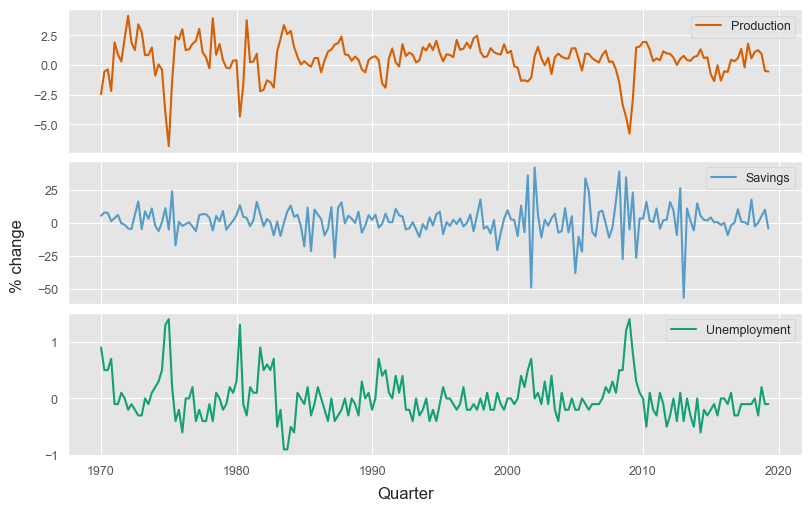

In [210]:
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)
sns.lineplot(data=us_change, x="ds", y="Production", ax=axes[0],
    color="#D55F03", label="Production")
sns.lineplot(data=us_change, x="ds", y="Savings", ax=axes[1],
    color="#569CC6", label="Savings")
sns.lineplot(data=us_change, x="ds", y="Unemployment", ax=axes[2],
    color="#13A076", label="Unemployment")
for ax in axes:
    ax.set(xlabel="", ylabel="")
fig.supxlabel("Quarter")
fig.supylabel("% change")
plt.show()

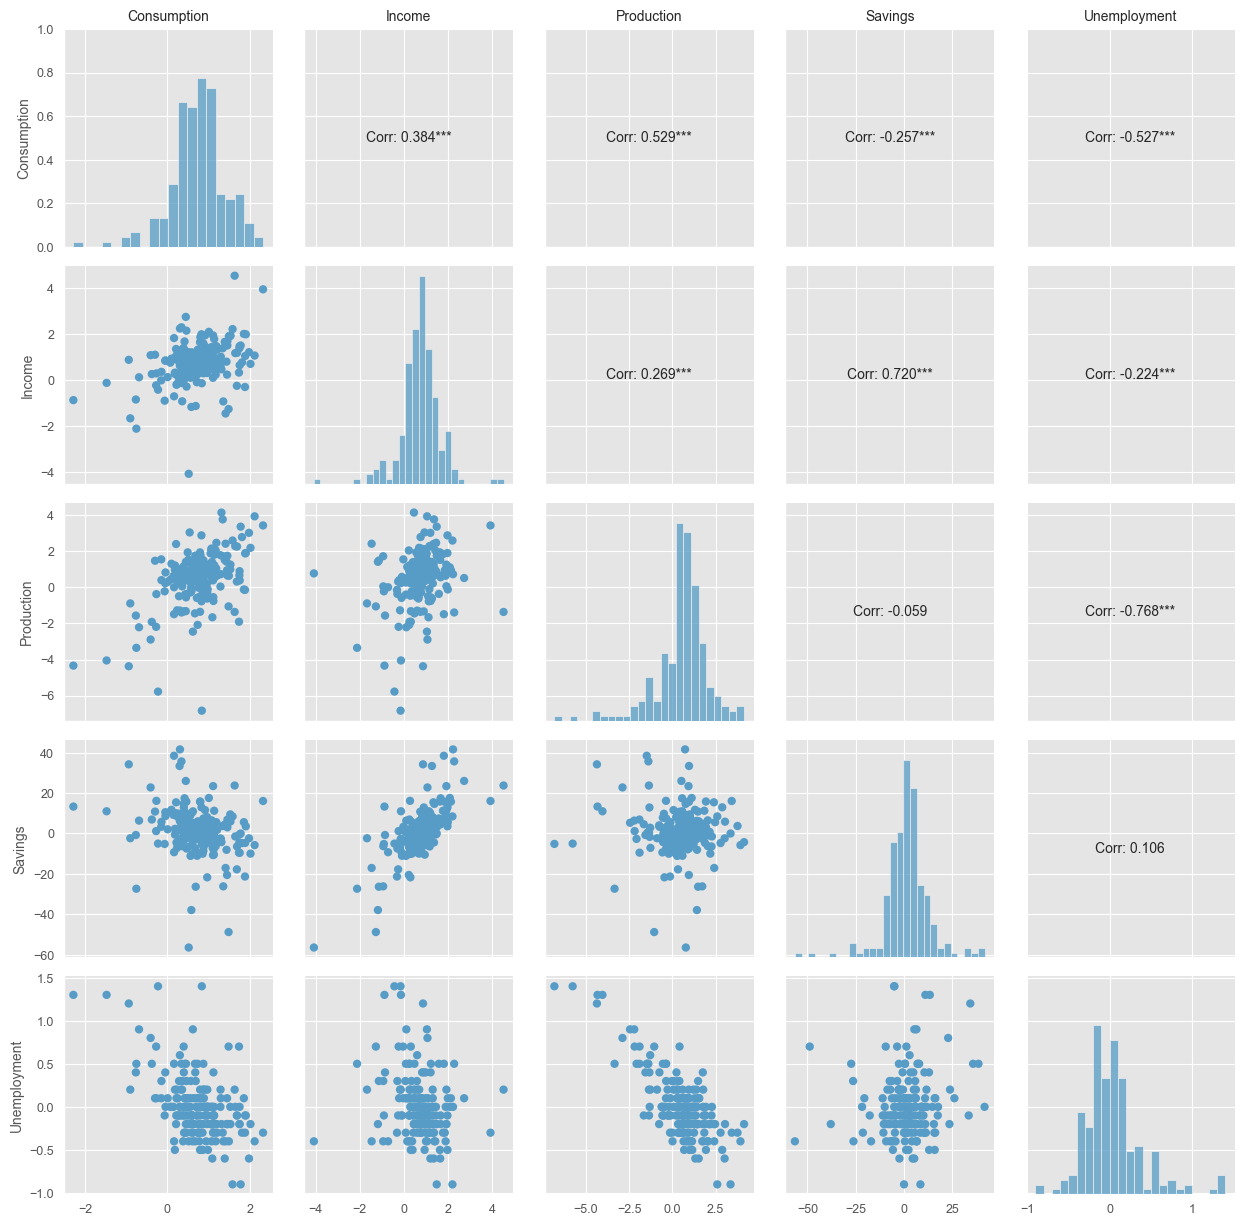

In [211]:
columns = ["y", "Income", "Production", "Savings", "Unemployment"]
df = us_change[columns].rename(columns={'y': 'Consumption'})

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: {r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center")

g = sns.PairGrid(df)
g.map_diag(sns.histplot)
g.map_upper(corrfunc)
g.map_lower(sns.scatterplot, edgecolor="none")
g.add_legend()
# Move x-axis labels to the top
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size='medium')
plt.show()

# 7.2 Least squares estimation


In [216]:
reg_df = us_change[[
    "unique_id", "ds", "y",
    "Income", "Production", "Savings", "Unemployment"
]].dropna()

mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(reg_df, fitted=True, static_features=[])

model = mf.models_["LinearRegression"]

X = reg_df.drop(columns=["unique_id", "ds", "y"])

model._X = X
model._y = reg_df["y"].values
model._residuals = model._y - model.predict(X)
model._var_names = X.columns.tolist()

print_regression_summary_from_model(model)

Residuals:
    Min     1Q  Median     3Q    Max
 -0.906 -0.158  -0.036  0.136  1.155

Coefficients:
              Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)      0.253       0.034    7.343  5.713e-12  ***
Income           0.741       0.040   18.461  0.000e+00  ***
Production       0.047       0.023    2.038  4.287e-02    *
Savings         -0.053       0.003  -18.088  0.000e+00  ***
Unemployment    -0.175       0.096   -1.829  6.895e-02    .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.310 on 193 degrees of freedom 
Multiple R-squared: 0.768,    Adjusted R-squared: 0.763 
F-statistic: 160.0 on 4 and 193 DF, p-value: 1.11e-16


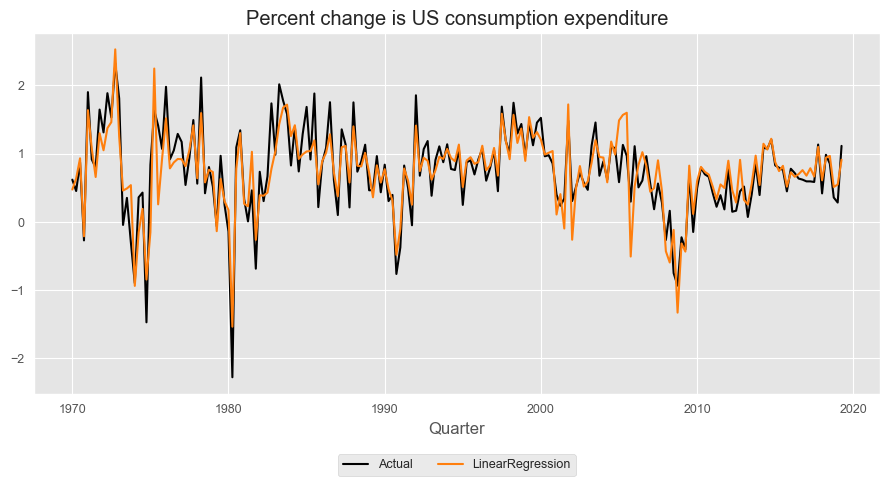

In [217]:
df = mf.forecast_fitted_values().drop(columns="y")

uid = df["unique_id"].iloc[0]

actual_df = us_change.loc[lambda x: x["unique_id"] == uid]
df = df.loc[lambda x: x["unique_id"] == uid]

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)

plt.plot(actual_df["ds"], actual_df["y"], color="black", label="Actual")
plt.plot(df["ds"], df["LinearRegression"], color="tab:orange", label="LinearRegression")

plt.xlabel("Quarter")
plt.ylabel("")
plt.title("Percent change is US consumption expenditure")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

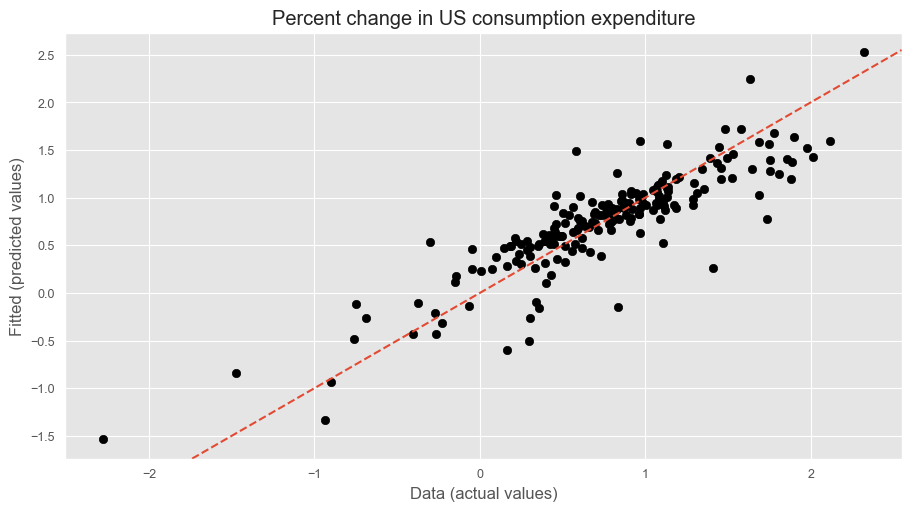

In [218]:
fig, ax = plt.subplots()
insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
ax.scatter(us_change["y"], insample_forecasts, color="k")
ax.axline((0, 0), (1, 1), linestyle="--")
ax.set(
    title="Percent change in US consumption expenditure",
    xlabel="Data (actual values)",
    ylabel="Fitted (predicted values)")
plt.show()